$f(x) = \frac{1}{2} x^T A x + b \cdot x$ \
$g(x) \leq 0$ \
$g(x) = \|x - x_0\| - r$ \
$A \in \mathbb{R}^{4 \times 4}$ — невырожденная симметричная **неопределённая** матрица (имеет собственные значения разных знаков) \
$b, x_0 \in \mathbb{R}^4$ \
$r > 0$ \
$\mathcal{X} = \{ x : \|x - x_0\| \leq r \}$.

# выражаем условия ККТ
Функция Лагранжа: $L(x,λ) = 0.5·x^T Ax + bx + \lambda (||x-x_0||^2 - r^2)$

### (1) Стационарность
$\nabla f(x) + \lambda  \nabla g(x) = 0$ \
$Ax + b + 2\lambda (x - x_0) = 0$ \
Приводим к виду системы относительно x: \
$(A + 2 \lambda I)·x = 2\lambda x_0 - b$ \
$x(\lambda) = (A + 2 \lambda I)^{-1}(2\lambda x_0 - b)$

### (2) Активность ограничения (на границе)
$||x - x_0||^2 - r^2 = 0$

### (3) Неотрицательность
$\lambda \ge 0$

### (4) Дополняющая нежёсткость
$\lambda \cdot (||x-x_0||^2 - r^2) = 0$

# совмещаем условия ККТ

$x(\lambda) = (A + 2 \lambda I)^{-1}(2\lambda x_0 - b)$ \
$||x - x_0||^2 - r^2 = 0$ \
получаем \
$g(x) = ||x(\lambda) - x_0||^2 - r^2 = 0$

# теперь получаем g'(x) для метода Ньютона

$d(\lambda) = x(\lambda) - x_0$ \
$g(\lambda) = d(\lambda)^T d(\lambda) - r^2$ \
$g'(\lambda) = 2d(\lambda)^T d'(\lambda) - r^2$ \
так как $d'(\lambda) = x'(\lambda)$ \
то $g'(\lambda) = 2(x(\lambda)-x_0)^T x'(\lambda)$ \
$x'(\lambda) = 2 (A + 2 \lambda I)^{-1} (x_0-x(\lambda))$


$g'(\lambda) = 2(x(\lambda)-x_0)^T (2(A + 2 \lambda I)^{-1} (x_0-x(\lambda)))$ \
$g'(\lambda) = -4(x(\lambda)-x_0)^T (A + 2 \lambda I)^{-1} (x(\lambda) - x_0)$


# Метод Ньютона (касательных)
$x_{n+1}=x_n - \frac{g(x_n)}{g'(x_n)}$ \
по нему и будем итерироваться

In [375]:
# импорты
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.optimize import minimize, NonlinearConstraint
from scipy.optimize import fsolve

In [376]:
# общие константы

# np.random.seed(42)
TOL = np.float64(1e-12)
START_LAMBDA = 1.238

In [377]:
# структура для констант уравнения
@dataclass
class Data:
    A: np.ndarray
    b: np.ndarray
    x0: np.ndarray
    r: np.floating
    

In [378]:
# вспомогательные функции
def x_lmbda(data: Data, lmbda: float):
    # $x(\lambda) = (A + 2 \lambda I)^{-1}(2\lambda x_0 - b)$
    return np.linalg.inv(data.A + 2.0 * lmbda * np.eye(data.A.shape[0])) @ (2.0*lmbda * data.x0 - data.b)

def x_lmbda_grad(data: Data, lmbda: float):
    # x'(\lambda) = 2 (A + 2 \lambda I)^{-1} (x_0-x(\lambda))
    return 2.0 * np.linalg.inv(data.A + 2.0 * lmbda * np.eye(data.A.shape[0])) @ (data.x0 - x_lmbda(data, lmbda))


def g_lmbda(data: Data, lmbda: float):
    # g(x) = ||x(\lambda) - x_0||^2 - r^2
    d = np.linalg.norm(x_lmbda(data, lmbda) - data.x0)
    return d * d - data.r**2

def g_lmbda_grad(data: Data, lmbda: float):
    # # g'(\lambda) = -4(x(\lambda)-x_0)^T (A + 2 \lambda I)^{-1} (x(\lambda) - x_0)
    return -4.0 * (x_lmbda(data, lmbda) - data.x0).T @ np.linalg.inv(data.A + 2.0 * lmbda * np.eye(data.A.shape[0])) @ (x_lmbda(data, lmbda) - data.x0)

def check_solving(data: Data, x: np.ndarray):
    return np.linalg.norm(x - data.x0) - data.r

def find_lmbda_by_x(data: Data, x: np.ndarray):
    diff = x - data.x0
    denom = 2.0 * np.dot(diff, diff)
    num = np.dot(diff, data.A @ x + data.b)
    lam = -num / denom
    return lam
    

In [379]:
def demonstrate(
    history: dict[str, list],
    lmbda_ideal: float | None = None,
    g_lmbda_norm_ideal: float | None = None,
    g_lmbda_grad_norm_ideal: float | None = None,
):
    fig, axes = plt.subplots(1, 3, figsize=(13, 5))

    iters = np.arange(1, len(history['lmbda']) + 1)

    # --- lmbda ---
    axes[0].plot(iters, history['lmbda'], color='steelblue', lw=2)
    if lmbda_ideal is not None:
        axes[0].axhline(lmbda_ideal, color='tomato', ls='--', lw=1.5, label=f'lmbda = {lmbda_ideal:.4f}')
    axes[0].set_xlabel('Итерация')
    axes[0].set_ylabel('lmbda')
    axes[0].set_title('график изменения лямбды')
    if lmbda_ideal is not None:
        axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # --- g(lmbda) ---
    axes[1].plot(iters, history['g_lmbda_norm'], color='steelblue', lw=2)
    if g_lmbda_norm_ideal is not None:
        axes[1].axhline(g_lmbda_norm_ideal, color='tomato', ls='--', lw=1.5, label=f'g(lmbda) = {g_lmbda_norm_ideal:.4f}')
    axes[1].set_xlabel('Итерация')
    axes[1].set_ylabel('g_lmbda_norm')
    axes[1].set_title('график изменения функции по ККТ')
    if g_lmbda_norm_ideal is not None:
        axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # --- g'(lmbda) ---
    axes[2].plot(iters, history['g_lmbda_grad_norm'], color='steelblue', lw=2)
    if g_lmbda_grad_norm_ideal is not None:
        axes[2].axhline(g_lmbda_grad_norm_ideal, color='tomato', ls='--', lw=1.5, label=f"g'(lmbda) = {g_lmbda_grad_norm_ideal:.4f}")
    axes[2].set_xlabel('Итерация')
    axes[2].set_ylabel('g_lmbda_grad_norm')
    axes[2].set_title('график изменения производной от функции по ККТ')
    if g_lmbda_grad_norm_ideal is not None:
        axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [380]:
# моё решение (нахождение лямбды)
def find_lmbda_by_iter(
    data: Data,
    lmbda: float = START_LAMBDA,
    max_iter: int = 500,
    tol: float = TOL
) -> float:
    history: dict[str, list] = {
        'g_lmbda_norm': [np.linalg.norm(g_lmbda(data, lmbda))],
        'g_lmbda_grad_norm': [np.linalg.norm(g_lmbda_grad(data, lmbda))],
        'lmbda': [lmbda]
    }

    for iter_num in range(max_iter):
        new_lmbda = lmbda - g_lmbda(data, lmbda) / g_lmbda_grad(data, lmbda)

        history['g_lmbda_norm'].append(np.linalg.norm(g_lmbda(data, new_lmbda)))
        history['g_lmbda_grad_norm'].append(np.linalg.norm(g_lmbda_grad(data, new_lmbda)))
        history['lmbda'].append(new_lmbda)

        if abs(new_lmbda - lmbda) < tol:
            lmbda = new_lmbda
            print("всего итераций:", iter_num + 1)
            break
        lmbda = new_lmbda
    else:
        print("Warning: Line search did not converge within the maximum number of iterations.")
    return lmbda, history

In [381]:
# идеальное решение без ККТ (нахождение икса)
def f(data: Data, x: np.ndarray):
    return 0.5 * x @ data.A @ x + data.b @ x

def f_grad(data: Data, x: np.ndarray):
    return data.A @ x + data.b


def get_ideal_result(
    data: Data,
    max_iter: int = 5_000,
    tol: np.floating = TOL,
):
    constraint = NonlinearConstraint(
        fun=lambda x: np.linalg.norm(x - data.x0),
        lb=-np.inf,
        ub=data.r
    )

    res = minimize(
        fun=lambda x: f(data, x),
        x0=data.x0,
        jac=lambda x: f_grad(data, x),
        method='SLSQP',
        constraints=constraint,
        options={'ftol': tol, 'maxiter': max_iter}
    )
    return res.x, res.fun

In [382]:
# идеальное решение по условиям ККТ (нахождение лямбды)
def get_ideal_lmbda(
    data: Data,
    tol: np.floating = TOL,
    lmbda: float = START_LAMBDA,
):
    return fsolve(lambda lmbda: g_lmbda(data, lmbda), lmbda, xtol=tol)

In [383]:
# константы для уравнения
A = [
    [-0.6333, -0.6542, 1.2504,  -1.2375],
    [-0.6542, 3.1035,  0.2128,  -0.32  ],
    [ 1.2504, 0.2128,  -1.4615, -0.6738],
    [-1.2375, -0.32,   -0.6738, -0.698 ],
]
b  = [1.0, -2.0, 0.5, 3.0]
x0 = [1.0, 1.0, 1.0, 1.0]
r  = 2.0
test_data = Data(A=np.array(A), b=np.array(b), x0=np.array(x0), r=np.float64(r))

# моё решение

In [384]:
# решение моим методом
lmbda_opt, hist = find_lmbda_by_iter(test_data)
x_opt = x_lmbda(test_data, lmbda_opt)
f_opt = f(test_data, x_opt)
print(f"lmbda_opt: {lmbda_opt:.6f}")
print(f"f_opt: {f_opt:.6f}")
print("x_opt:", x_opt)

всего итераций: 5
lmbda_opt: 1.238301
f_opt: -3.755403
x_opt: [ 2.42681394  1.18382687 -0.29856005  1.49411685]


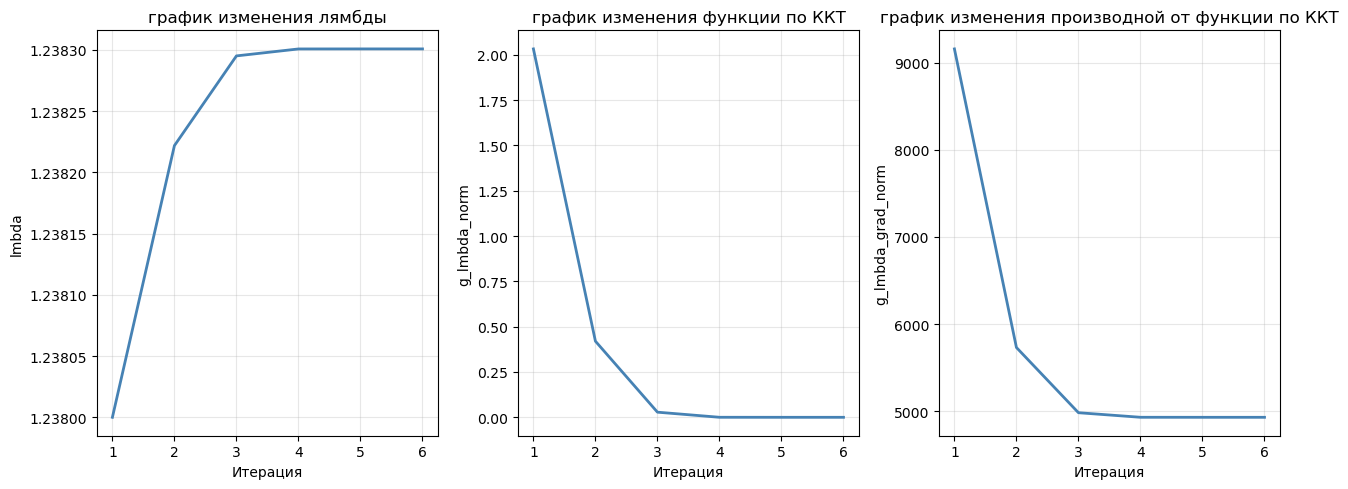

In [385]:
demonstrate(hist)

# идеальное решение по условиям ККТ

In [386]:
# запуск идеального решения по ККТ
lmbda_ideal, *_ = get_ideal_lmbda(test_data)
x_ideal = x_lmbda(test_data, lmbda_ideal)
f_ideal = f(test_data, x_ideal)

g_lmbda_norm_ideal = np.linalg.norm(g_lmbda(test_data, lmbda_ideal))
g_lmbda_grad_norm_ideal = np.linalg.norm(g_lmbda_grad(test_data, lmbda_ideal))


print(f"lmbda_ideal: {lmbda_ideal:.6f}")
print(f"f_ideal: {f_ideal:.6f}")
print("x_ideal:", x_ideal)

print(f"лямбда: результат: {lmbda_opt:.8f}, результат идельного решения: {lmbda_ideal:.8f}")
print(f"лямбда: точность: {(lmbda_opt - lmbda_ideal):.4e}")
print(f"результат: {f_opt:.8f}, результат идельного решения: {f_ideal:.8f}")
print(f"точность: {(f_opt - f_ideal):.4e}")

lmbda_ideal: 1.238301
f_ideal: -3.755403
x_ideal: [ 2.42681394  1.18382687 -0.29856005  1.49411685]
лямбда: результат: 1.23830087, результат идельного решения: 1.23830087
лямбда: точность: 0.0000e+00
результат: -3.75540334, результат идельного решения: -3.75540334
точность: 0.0000e+00


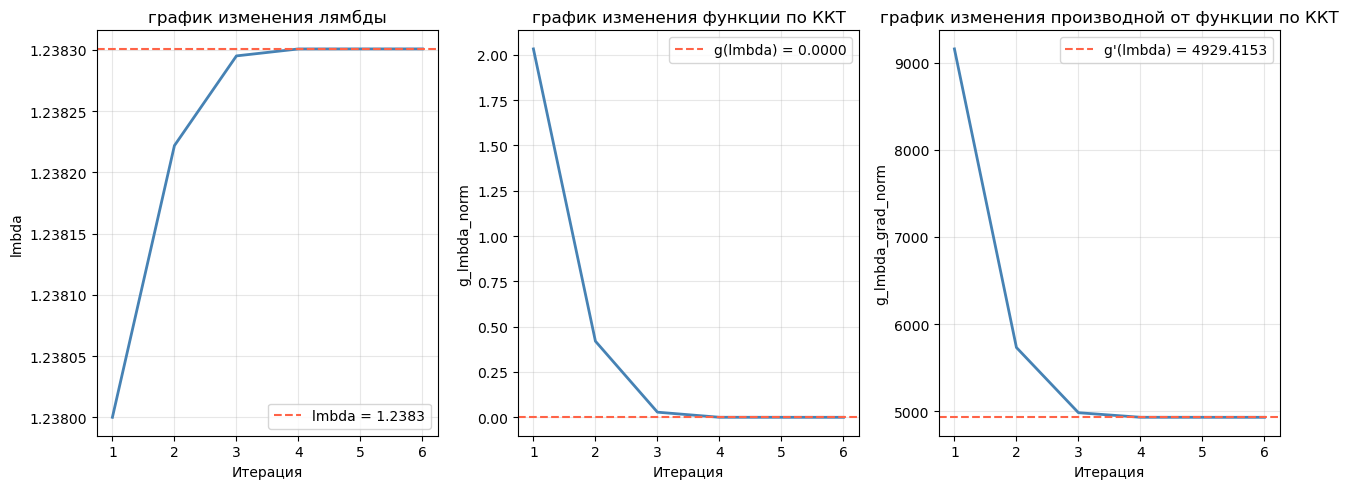

In [387]:
demonstrate(hist, lmbda_ideal, g_lmbda_norm_ideal, g_lmbda_grad_norm_ideal)

# идеальное решение

In [388]:
# запуск идеального решения без ККТ
x_ideal, f_ideal = get_ideal_result(test_data)
lmbda_ideal = find_lmbda_by_x(test_data, x_ideal)
g_lmbda_norm_ideal = np.linalg.norm(g_lmbda(test_data, lmbda_ideal))
g_lmbda_grad_norm_ideal = np.linalg.norm(g_lmbda_grad(test_data, lmbda_ideal))

print(f"lmbda_ideal: {lmbda_ideal:.6f}")
print(f"f_ideal: {f_ideal:.6f}")
print("x_ideal:", x_ideal)


print(f"лямбда: результат: {lmbda_opt:.8f}, результат идельного решения: {lmbda_ideal:.8f}")
print(f"лямбда: точность: {(lmbda_opt - lmbda_ideal):.4e}")
print(f"результат: {f_opt:.8f}, результат идельного решения: {f_ideal:.8f}")
print(f"точность: {(f_opt - f_ideal):.4e}")

lmbda_ideal: 1.238301
f_ideal: -3.755403
x_ideal: [ 2.42681394  1.18382689 -0.29856002  1.49411691]
лямбда: результат: 1.23830087, результат идельного решения: 1.23830087
лямбда: точность: -7.5625e-10
результат: -3.75540334, результат идельного решения: -3.75540334
точность: 3.1850e-12


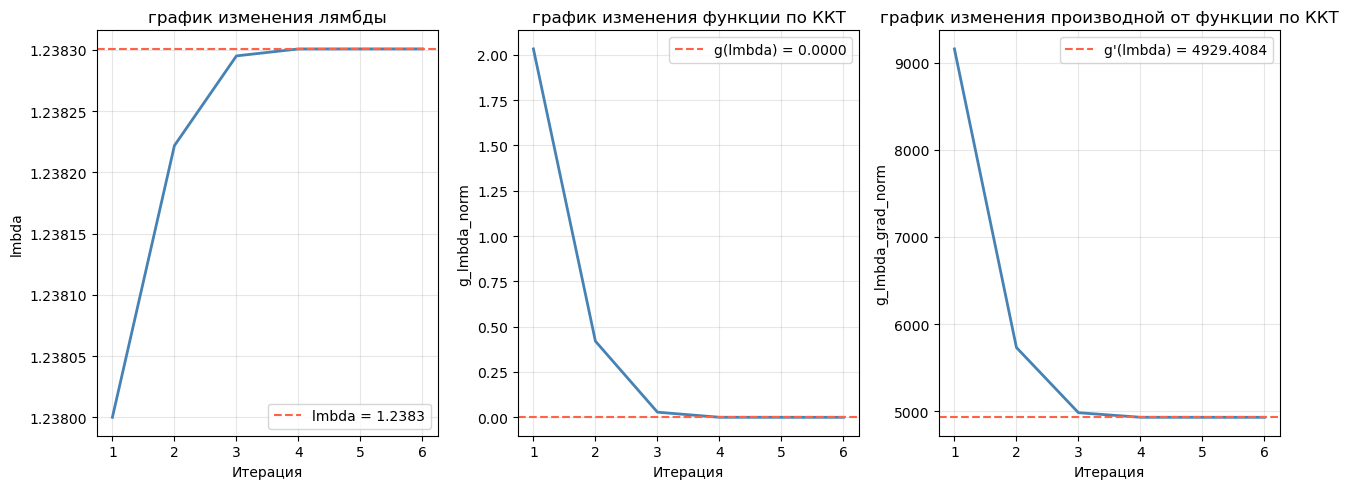

In [389]:
demonstrate(hist, lmbda_ideal, g_lmbda_norm_ideal, g_lmbda_grad_norm_ideal)